# Fair Comparison: MPS vs TTN Classification

Head-to-head Born-machine classifiers on the **same** synthetic drift dataset,
encoder, hyperparameters, and validation protocol.

| Setting | Value |
|---------|-------|
| Data seed | 42 (train), 42 continued (test) |
| Init seed | 1 (both models) |
| `D_max` | 32 |
| `η` | 5e-4 with `cosine_lr` |
| Epochs | 100, patience 10 on `xi_test` |

Both models joint-train `p(ξ, y)` via NLL; inference uses Born-rule
`p(y|ξ) ∝ |Ψ(ξ, y)|²`.

Compare with the generative Heston results in `mps_vs_ttn_comparison.ipynb`:
classification only needs `p(y|path)`, not faithful path sampling.

In [1]:
import Pkg
Pkg.activate(joinpath(@__DIR__, "../.."))
Pkg.resolve()
Pkg.instantiate()

using MPSFast
using MPSFast.Encoders
using Random, LinearAlgebra, Statistics, Printf
using Plots

  Activating project at `~/dev/Notes on Time Series Generation for Options Pricing/repos/MPSFast.jl`
     Project No packages added to or removed from `~/dev/Notes on Time Series Generation for Options Pricing/repos/MPSFast.jl/Project.toml`
    Manifest No packages added to or removed from `~/dev/Notes on Time Series Generation for Options Pricing/repos/MPSFast.jl/Manifest.toml`


## 1. Shared dataset & encoding

In [2]:
function synthetic_paths_labels(N, M; drift=0.15, σ=1.0, rng=Random.default_rng())
    paths  = Matrix{Float64}(undef, N, M)
    labels = Vector{Int}(undef, N)
    for i in 1:N
        y = rand(rng, 1:2)
        d = y == 1 ? drift : -drift
        s = cumsum(d .+ σ .* randn(rng, M))
        paths[i,  :] = s
        labels[i]    = y
    end
    return paths, labels
end

rng = MersenneTwister(42)
N_train, N_test, M = 2_000, 500, 15
n_classes = 2

train_paths, train_labels = synthetic_paths_labels(N_train, M; rng=rng)
test_paths,  test_labels  = synthetic_paths_labels(N_test,  M; rng=rng)

enc = BasisEncoder(3)
fit_grid!(enc, train_paths)

xi_train = encode_labeled_paths(enc, train_paths, train_labels; n_classes=n_classes)
xi_test  = encode_labeled_paths(enc, test_paths,  test_labels;  n_classes=n_classes)
xi_test_path = encode_paths(enc, test_paths)

Ml_class = classification_chain_length(enc, M)
d_class  = site_dim(enc)

println("Train: ", size(xi_train), "  Test: ", size(xi_test))
println("Joint sites: ", Ml_class, "  d_path=", d_class)

Train: (2000, 16)  Test: (500, 16)
Joint sites: 16  d_path=8


## 2. Initialise both models (same RNG seed)

In [3]:
D_max = 32
init_rng = MersenneTwister(1)

function init_mps_classification(Ml, d_path, n_classes, D_max; rng=Random.default_rng())
    T = Float32
    Ds = [1; [min(d_path^j, D_max) for j in 1:Ml-1]; 1]
    mps = [randn(rng, T, Ds[j], d_path, Ds[j+1]) for j in 1:Ml-1]
    push!(mps, randn(rng, T, Ds[Ml], n_classes, 1))
    left_canonicalize_mps!(mps)
    return mps
end

mps = init_mps_classification(Ml_class, d_class, n_classes, D_max; rng=init_rng)
ttn = init_ttn_classification(M, d_class, n_classes, D_max; rng=init_rng)

println("MPS sites: ", length(mps), "  TTN sites: ", ttn.n_sites, "  N_pad: ", ttn.N_pad)

MPS sites: 16  TTN sites: 16  N_pad: 16


## 3. Train with matched hyperparameters

In [4]:
n_epochs = 100
η        = 5e-4
ε_cut    = 1e-5
patience = 10

mps_val_nll = Float64[]
ttn_val_nll = Float64[]

println("=== Training MPS ===")
t_mps = @elapsed begin
    mps_nll_hist = train_mps!(
        mps, xi_train, n_epochs, η, D_max, ε_cut;
        verbose     = true,
        nll_samples = 500,
        lr_schedule = cosine_lr,
        val_data    = xi_test,
        val_samples = N_test,
        patience    = patience,
        val_nll_log = mps_val_nll,
    )
end

println("\n=== Training TTN ===")
t_ttn = @elapsed begin
    ttn_nll_hist = train_ttn!(
        ttn, xi_train, n_epochs, η, D_max;
        verbose     = true,
        nll_samples = 500,
        lr_schedule = cosine_lr,
        val_data    = xi_test,
        val_samples = N_test,
        patience    = patience,
        val_nll_log = ttn_val_nll,
    )
end

println("\nWall time:  MPS ", round(t_mps, digits=1), " s  |  TTN ", round(t_ttn, digits=1), " s")

=== Training MPS ===
train_mps!: Ml=16, Nd=2000, d=8, D_max=32, epochs=100, one-hot
— Epoch 1/100 —
  ↳ norm envs ready → forward sweep (15 bonds) …
  ↳ forward done → canonicalize + rebuild envs + backward sweep …
  ↳ backward done → canonicalize + NLL estimate …
Epoch 1/100 | NLL ≈ 20.2123 | η=0.0005 | bonds=[8,32,32,32,32,32,32,32,32,32,32,32,32,16,2] | 0.306 s
  ↳ val NLL ≈ 20.8378  (patience 0/10)
— Epoch 2/100 —
  ↳ norm envs ready → forward sweep (15 bonds) …
  ↳ forward done → canonicalize + rebuild envs + backward sweep …
  ↳ backward done → canonicalize + NLL estimate …
Epoch 2/100 | NLL ≈ 17.3237 | η=0.0005 | bonds=[8,32,32,32,32,32,32,32,32,32,32,32,32,16,2] | 0.117 s
  ↳ val NLL ≈ 17.7978  (patience 0/10)
— Epoch 3/100 —
  ↳ norm envs ready → forward sweep (15 bonds) …
  ↳ forward done → canonicalize + rebuild envs + backward sweep …
  ↳ backward done → canonicalize + NLL estimate …
Epoch 3/100 | NLL ≈ 15.7357 | η=0.0005 | bonds=[8,32,32,32,32,32,32,32,32,32,32,32,32,16,2]

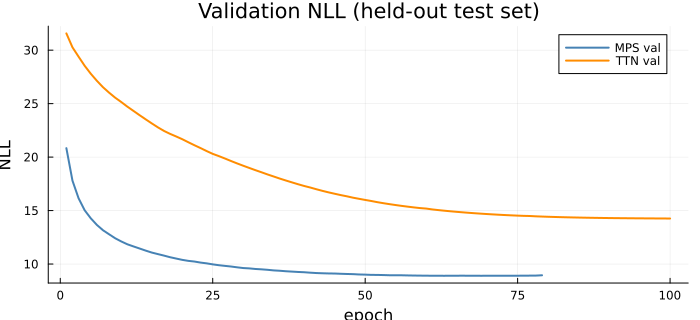

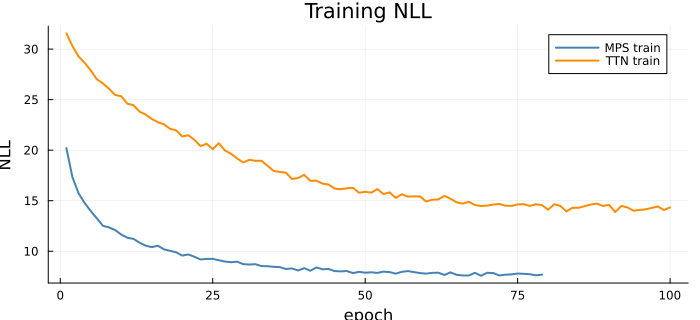

In [5]:
p_nll = plot(title="Validation NLL (held-out test set)", legend=:topright, size=(700, 320))
plot!(p_nll, mps_val_nll, label="MPS val", lw=2, color=:steelblue)
plot!(p_nll, ttn_val_nll, label="TTN val", lw=2, color=:darkorange)
xlabel!(p_nll, "epoch"); ylabel!(p_nll, "NLL")
display(p_nll)

p_nll2 = plot(title="Training NLL", legend=:topright, size=(700, 320))
plot!(p_nll2, mps_nll_hist, label="MPS train", lw=2, color=:steelblue)
plot!(p_nll2, ttn_nll_hist, label="TTN train", lw=2, color=:darkorange)
xlabel!(p_nll2, "epoch"); ylabel!(p_nll2, "NLL")
display(p_nll2)

## 4. Classification accuracy

Model     Train acc   Test acc    Train NLL      Val NLL
MPS           78.5%      65.0%        7.685        8.952
TTN           67.0%      64.2%       14.346       14.258


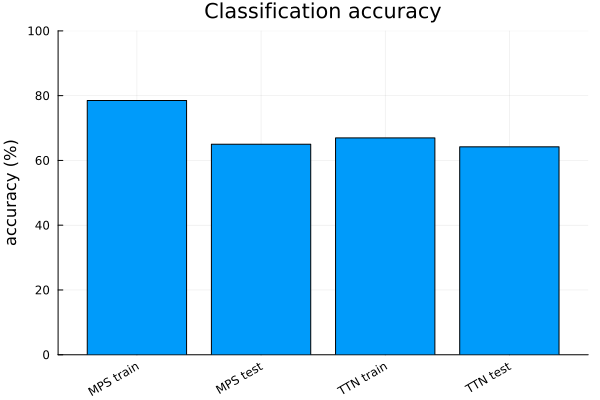

In [6]:
mps_acc_train = classification_accuracy(mps, xi_train, n_classes)
mps_acc_test  = classification_accuracy(mps, xi_test,  n_classes)
ttn_acc_train = classification_accuracy_ttn(ttn, xi_train, n_classes)
ttn_acc_test  = classification_accuracy_ttn(ttn, xi_test,  n_classes)

@printf "%-8s %10s %10s %12s %12s\n" "Model" "Train acc" "Test acc" "Train NLL" "Val NLL"
@printf "%-8s %9.1f%% %9.1f%% %12.3f %12.3f\n" "MPS" 100mps_acc_train 100mps_acc_test mps_nll_hist[end] mps_val_nll[end]
@printf "%-8s %9.1f%% %9.1f%% %12.3f %12.3f\n" "TTN" 100ttn_acc_train 100ttn_acc_test ttn_nll_hist[end] ttn_val_nll[end]

bar(["MPS train", "MPS test", "TTN train", "TTN test"],
    [100mps_acc_train, 100mps_acc_test, 100ttn_acc_train, 100ttn_acc_test],
    ylabel="accuracy (%)", title="Classification accuracy",
    legend=false, ylim=(0, 100), xrotation=30)

## 5. Confusion matrices (test set)

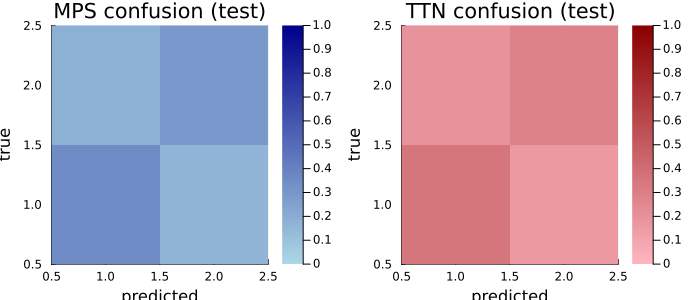

In [10]:
function confusion_matrix(model, xi_path, labels, n_classes; ttn=false)
    C = zeros(Int, n_classes, n_classes)
    for i in 1:length(labels)
        y_pred = ttn ?
            predict_class_ttn(model, xi_path[i, :], n_classes) :
            predict_class(model, xi_path[i, :], n_classes)
        C[labels[i], y_pred] += 1
    end
    return C ./ sum(C)
end

Cmps = confusion_matrix(mps, xi_test_path, test_labels, n_classes)
Cttn = confusion_matrix(ttn, xi_test_path, test_labels, n_classes; ttn=true)

hm_mps = heatmap(Cmps, title="MPS confusion (test)", xlabel="predicted", ylabel="true",
                 color=:blues, clims=(0, 1))
hm_ttn = heatmap(Cttn, title="TTN confusion (test)", xlabel="predicted", ylabel="true",
                 color=:reds, clims=(0, 1))
plot(hm_mps, hm_ttn, layout=(1, 2), size=(700, 300))

## 6. Logistic regression baseline

In [11]:
function logreg_features(paths)
    hcat(paths[:, end], mean(paths, dims=2)[:], std(paths, dims=2)[:])
end
sigmoid(z) = 1 ./ (1 .+ exp.(-z))

function logreg_train(X, y; lr=0.1, n_iter=500)
    n, p = size(X); w = zeros(p); b = 0.0
    for _ in 1:n_iter
        err = sigmoid(X * w .+ b) .- (y .== 1)
        w -= lr / n .* (X' * err)
        b -= lr / n .* sum(err)
    end
    return w, b
end

X_train = logreg_features(train_paths)
X_test  = logreg_features(test_paths)
w, b    = logreg_train(X_train, train_labels)
lr_test = mean((sigmoid(X_test * w .+ b) .> 0.5) .+ 1 .== test_labels)

println("Logistic regression test accuracy: ", round(100 * lr_test, digits=1), "%")

Logistic regression test accuracy: 25.2%


## 7. Discussion

**Generative vs discriminative gap.** On Heston path generation, the MPS chain
preserves lag-1 bucket correlation (~0.78 samples vs ~0.91 data) while the TTN
collapses it (~0.15). That pathology does **not** automatically hurt
classification: here we only need `p(y | ξ)`, a low-dimensional marginal of the
joint Born amplitude.

**What to look for in the plots above:**
- If TTN test accuracy is competitive despite higher NLL, the tree topology
  still captures label-relevant path features even when sequential sampling fails.
- If MPS wins on both NLL and accuracy, the time-ordered chain is better matched
  to this task at equal bond dimension.
- Train–test gap: a large gap for either model suggests overfitting the joint
  distribution; both use the same early-stopping criterion for fairness.

**Protocol notes:** identical `cosine_lr`, validation on the full 500-point test
set, and the same init seed. TTN epochs are slower per sweep (tree topology);
see wall-clock timings in §3.